### FINE-TUNING RESNET-18

In [1]:
# Import libraries
from pathlib import Path
import sys
import random
import yaml

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch.utils.data import DataLoader


In [2]:
# Project paths

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "src").is_dir():
    raise FileNotFoundError("Project src/ folder not found")

PROCESSED_DATA_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
)

CHECKPOINT_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "checkpoints"
)

FIGURES_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "figures"
)

METRICS_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "metrics"
)

CONFIG_PATH = (
    PROJECT_ROOT
    / "configs"
    / "fine_tuning.yaml"
)

CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

METRICS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

print("Project root:", PROJECT_ROOT)
print("Fine-tuning config:", CONFIG_PATH)


Project root: C:\Deep Learning\skin-lesion-classification
Fine-tuning config: C:\Deep Learning\skin-lesion-classification\configs\fine_tuning.yaml


In [3]:
# Import project modules

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(
        0,
        str(PROJECT_ROOT),
    )

from src.data.dataset import (
    HAM10000Dataset,
    HAM10000_CLASSES,
)

from src.data.preprocessing import (
    get_eval_transform,
)

from src.data.augmentation import (
    get_train_transform,
)

from src.models.transfer_learning import (
    TransferLearningResNet18,
)

from src.training.losses import (
    compute_class_weights,
)

from src.training.train import (
    fit,
)

from src.models.fine_tuning import (
    configure_resnet18_fine_tuning,
    get_fine_tuning_criterion,
    get_fine_tuning_optimizer,
    get_fine_tuning_scheduler,
    count_trainable_parameters,
)


In [4]:
# Load fine-tuning configuration

if not CONFIG_PATH.exists():
    raise FileNotFoundError(
        f"Fine-tuning config not found: {CONFIG_PATH}\n"
        "Create configs/fine_tuning.yaml before running Part 8."
    )

with open(
    CONFIG_PATH,
    "r",
    encoding="utf-8",
) as file:
    config = yaml.safe_load(file)

config


{'experiment': {'name': 'fine_tuned_resnet18', 'seed': 42},
 'data': {'image_size': 224,
  'batch_size': 32,
  'num_workers': 0,
  'num_classes': 7},
 'model': {'name': 'resnet18',
  'pretrained': True,
  'dropout': 0.3,
  'hidden_dim': 256,
  'checkpoint': 'outputs/checkpoints/transfer_resnet18_best.pt'},
 'fine_tuning': {'strategy': 'progressive',
  'frozen_modules': ['conv1', 'bn1', 'layer1', 'layer2', 'layer3'],
  'trainable_modules': ['layer4', 'fc']},
 'loss': {'name': 'weighted_cross_entropy',
  'class_weight_strategy': 'sqrt_inverse_frequency',
  'label_smoothing': 0.05},
 'optimizer': {'name': 'AdamW',
  'backbone_lr': 1e-05,
  'classifier_lr': 0.0001,
  'weight_decay': 0.0001},
 'scheduler': {'name': 'ReduceLROnPlateau',
  'mode': 'min',
  'factor': 0.5,
  'patience': 2,
  'min_lr': 1e-07},
 'training': {'epochs': 15,
  'early_stopping_patience': 5,
  'monitor': 'val_loss'},
 'outputs': {'checkpoint': 'outputs/checkpoints/fine_tuned_resnet18_best.pt',
  'history': 'outputs/me

In [5]:
# Reproducibility

SEED = config["experiment"]["seed"]

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Random seed:", SEED)


Random seed: 42


In [6]:
# Device

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Using device:", device)

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0),
    )


Using device: cpu


In [7]:
# Load the fixed Train / Validation / Test split

train_df = pd.read_csv(
    PROCESSED_DATA_DIR
    / "train.csv"
)

val_df = pd.read_csv(
    PROCESSED_DATA_DIR
    / "val.csv"
)

test_df = pd.read_csv(
    PROCESSED_DATA_DIR
    / "test.csv"
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))


Train: 6981
Validation: 1532
Test: 1502


In [8]:
# Image transforms

IMAGE_SIZE = config["data"]["image_size"]

train_transform = get_train_transform(
    image_size=IMAGE_SIZE,
)

eval_transform = get_eval_transform(
    image_size=IMAGE_SIZE,
)

print("Image size:", IMAGE_SIZE)


Image size: 224


In [9]:
# Datasets

train_dataset = HAM10000Dataset(
    dataframe=train_df,
    project_root=PROJECT_ROOT,
    transform=train_transform,
)

val_dataset = HAM10000Dataset(
    dataframe=val_df,
    project_root=PROJECT_ROOT,
    transform=eval_transform,
)

test_dataset = HAM10000Dataset(
    dataframe=test_df,
    project_root=PROJECT_ROOT,
    transform=eval_transform,
)


In [10]:
# DataLoaders

BATCH_SIZE = config["data"]["batch_size"]
NUM_WORKERS = config["data"]["num_workers"]

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print("Batch size:", BATCH_SIZE)


Batch size: 32


In [11]:
# Reconstruct the exact pretrained ResNet18 512 -> 256 -> 7 architecture.
NUM_CLASSES = int(config["data"]["num_classes"])
DROPOUT = float(config["model"]["dropout"])
model = TransferLearningResNet18(num_classes=NUM_CLASSES, dropout=DROPOUT, pretrained=False, freeze_backbone=True, hidden_dim=256).to(device)
print(model)


TransferLearningResNet18(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affi

In [12]:
# Check transfer checkpoint presence without changing trained weights.
TRANSFER_CHECKPOINT = PROJECT_ROOT / "outputs/checkpoints/transfer_resnet18_best.pt"
if not TRANSFER_CHECKPOINT.is_file():
    raise FileNotFoundError(f"Missing transfer checkpoint: {TRANSFER_CHECKPOINT}")
print("Existing transfer checkpoint:", TRANSFER_CHECKPOINT)


Existing transfer checkpoint: C:\Deep Learning\skin-lesion-classification\outputs\checkpoints\transfer_resnet18_best.pt


In [13]:
# Configure progressive fine-tuning

model = configure_resnet18_fine_tuning(
    model
)

stats = count_trainable_parameters(
    model
)

print(
    f"Total parameters:     "
    f"{stats['total']:,}"
)

print(
    f"Trainable parameters: "
    f"{stats['trainable']:,}"
)

print(
    f"Frozen parameters:    "
    f"{stats['frozen']:,}"
)

print(
    f"Trainable ratio:      "
    f"{stats['trainable_ratio'] * 100:.2f}%"
)

print("\nTrainable parameter groups:")

for name, parameter in model.named_parameters():
    if parameter.requires_grad:
        print(name)


Total parameters:     11,309,639
Trainable parameters: 8,526,855
Frozen parameters:    2,782,784
Trainable ratio:      75.39%

Trainable parameter groups:
backbone.layer4.0.conv1.weight
backbone.layer4.0.bn1.weight
backbone.layer4.0.bn1.bias
backbone.layer4.0.conv2.weight
backbone.layer4.0.bn2.weight
backbone.layer4.0.bn2.bias
backbone.layer4.0.downsample.0.weight
backbone.layer4.0.downsample.1.weight
backbone.layer4.0.downsample.1.bias
backbone.layer4.1.conv1.weight
backbone.layer4.1.bn1.weight
backbone.layer4.1.bn1.bias
backbone.layer4.1.conv2.weight
backbone.layer4.1.bn2.weight
backbone.layer4.1.bn2.bias
backbone.fc.0.weight
backbone.fc.0.bias
backbone.fc.3.weight
backbone.fc.3.bias


In [14]:
# Class weights

raw_class_weights = compute_class_weights(
    train_df=train_df,
    class_names=HAM10000_CLASSES,
    device=device,
)

criterion_ft, fine_tune_class_weights = (
    get_fine_tuning_criterion(
        raw_class_weights=raw_class_weights,
        label_smoothing=config["loss"]["label_smoothing"],
    )
)

print("Original class weights:")
print(raw_class_weights)

print("\nSoftened fine-tuning class weights:")
print(fine_tune_class_weights)

print("\nCriterion:")
print(criterion_ft)


Original class weights:
tensor([ 4.4923,  2.7626,  1.2918, 14.0463,  1.2901,  0.2130, 10.0736])

Softened fine-tuning class weights:
tensor([2.1195, 1.6621, 1.1366, 3.7478, 1.1358, 0.4615, 3.1739])

Criterion:
CrossEntropyLoss()


In [15]:
# Optimizer with discriminative learning rates

optimizer_ft = get_fine_tuning_optimizer(
    model=model,
    backbone_lr=config["optimizer"]["backbone_lr"],
    classifier_lr=config["optimizer"]["classifier_lr"],
    weight_decay=config["optimizer"]["weight_decay"],
)

print(
    "Backbone LR:",
    config["optimizer"]["backbone_lr"],
)

print(
    "Classifier LR:",
    config["optimizer"]["classifier_lr"],
)

print(optimizer_ft)


Backbone LR: 1e-05
Classifier LR: 0.0001
AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 1e-05
    maximize: False
    weight_decay: 0.0001

Parameter Group 1
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0.0001
)


In [16]:
# Learning-rate scheduler

scheduler_ft = get_fine_tuning_scheduler(
    optimizer=optimizer_ft,
    factor=config["scheduler"]["factor"],
    patience=config["scheduler"]["patience"],
    min_lr=config["scheduler"]["min_lr"],
)

print(scheduler_ft)


In [17]:
# Read the already-trained fine-tuned checkpoint and saved training history.
FINE_TUNED_CHECKPOINT = PROJECT_ROOT / "outputs/checkpoints/fine_tuned_resnet18_best.pt"
FINE_TUNING_HISTORY = PROJECT_ROOT / "outputs/metrics/fine_tuned_resnet18_training_history.csv"
if not FINE_TUNED_CHECKPOINT.is_file():
    raise FileNotFoundError(f"Missing fine-tuned checkpoint: {FINE_TUNED_CHECKPOINT}")
if not FINE_TUNING_HISTORY.is_file():
    candidates = sorted(METRICS_DIR.glob("*fine_tuned_resnet18*history*.csv"))
    FINE_TUNING_HISTORY = candidates[0] if candidates else FINE_TUNING_HISTORY
if FINE_TUNING_HISTORY.is_file():
    fine_tune_history_df = pd.read_csv(FINE_TUNING_HISTORY)
else:
    fine_tune_history_df = pd.DataFrame(columns=["epoch","train_loss","val_loss","train_accuracy","val_accuracy"])
    print("No saved fine-tuning history found; no plots available.")
print("No fine-tuning performed. Checkpoint preserved:", FINE_TUNED_CHECKPOINT)


No fine-tuning performed. Checkpoint preserved: C:\Deep Learning\skin-lesion-classification\outputs\checkpoints\fine_tuned_resnet18_best.pt


In [18]:
# Training history
fine_tune_history_df


,epoch,train_loss,train_accuracy,val_loss,val_accuracy,learning_rate
0,1,1.344301,0.734708,1.342673,0.708225,0.00001
1,2,1.270831,0.756339,1.316986,0.744125,0.00001
2,3,1.234129,0.767082,1.275070,0.748042,0.00001
3,4,1.233056,0.773098,1.269257,0.756527,0.00001
4,5,1.203966,0.782839,1.244030,0.761749,0.00001
5,6,1.170900,0.795015,1.246242,0.769582,0.00001
6,7,1.173265,0.791291,1.240062,0.767624,0.00001
7,8,1.135740,0.801461,1.238761,0.761097,0.00001
8,9,1.121539,0.805186,1.232878,0.766971,0.00001
9,10,1.112495,0.806045,1.227020,0.763708,0.00001


In [19]:
# Reconstruct and load the FINISHED fine-tuned weights, not the transfer weights.
from src.checkpoint_io import load_model
model = load_model(model, FINE_TUNED_CHECKPOINT, device)
model.eval()
print("Fine-tuned checkpoint loaded:", FINE_TUNED_CHECKPOINT)


C:\Deep Learning\skin-lesion-classification\src\checkpoint_io.py:60: RuntimeWarning: Using legacy torch.load for a trusted local HAM10000 checkpoint. Untrusted .pt files can execute code when unpickled.
  obj = _trusted_legacy_load(path)


Fine-tuned checkpoint loaded: C:\Deep Learning\skin-lesion-classification\outputs\checkpoints\fine_tuned_resnet18_best.pt


In [20]:
# Inspect best saved validation epoch, if history exists.
if fine_tune_history_df.empty:
    print("Training history unavailable; checkpoint can still be evaluated.")
else:
    best_ft_row = fine_tune_history_df.loc[fine_tune_history_df["val_loss"].idxmin()]
    print("Best fine-tuning epoch:")
    print(best_ft_row)


Best fine-tuning epoch:
epoch             14.000000
train_loss         1.056843
train_accuracy     0.828821
val_loss           1.192326
val_accuracy       0.785248
learning_rate      0.000010
Name: 13, dtype: float64


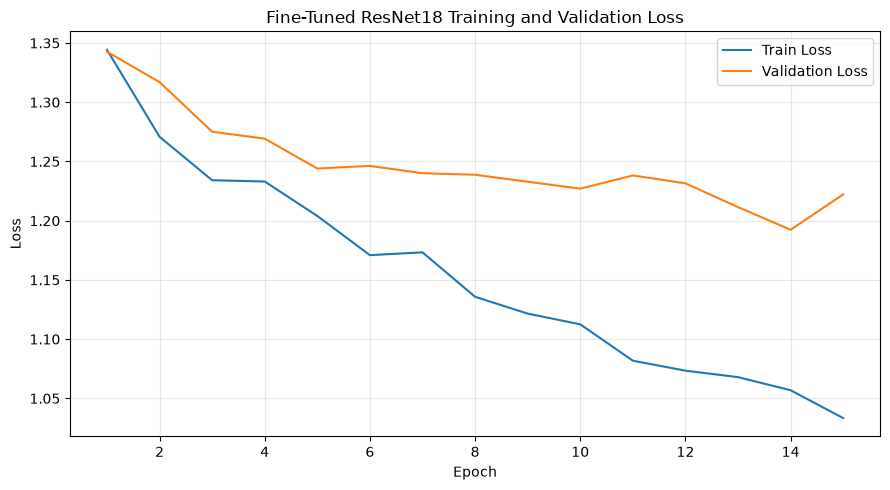

Saved: C:\Deep Learning\skin-lesion-classification\outputs\figures\fine_tuned_resnet18_loss_curve.png


In [21]:
# Plot loss curves

plt.figure(
    figsize=(9, 5)
)

plt.plot(
    fine_tune_history_df["epoch"],
    fine_tune_history_df["train_loss"],
    label="Train Loss",
)

plt.plot(
    fine_tune_history_df["epoch"],
    fine_tune_history_df["val_loss"],
    label="Validation Loss",
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Fine-Tuned ResNet18 "
    "Training and Validation Loss"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

LOSS_FIGURE = (
    PROJECT_ROOT
    / config["outputs"]["loss_figure"]
)

plt.savefig(
    LOSS_FIGURE,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    LOSS_FIGURE,
)


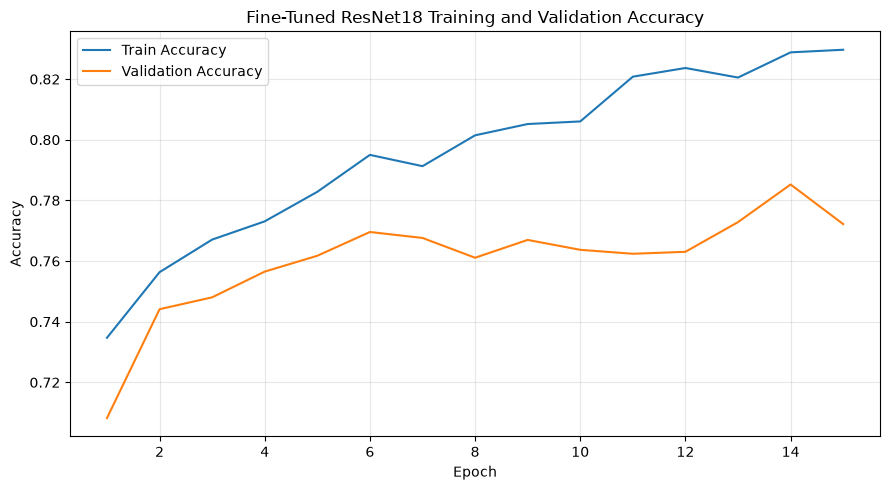

Saved: C:\Deep Learning\skin-lesion-classification\outputs\figures\fine_tuned_resnet18_accuracy_curve.png


In [22]:
# Plot accuracy curves

plt.figure(
    figsize=(9, 5)
)

plt.plot(
    fine_tune_history_df["epoch"],
    fine_tune_history_df["train_accuracy"],
    label="Train Accuracy",
)

plt.plot(
    fine_tune_history_df["epoch"],
    fine_tune_history_df["val_accuracy"],
    label="Validation Accuracy",
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "Fine-Tuned ResNet18 "
    "Training and Validation Accuracy"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

ACCURACY_FIGURE = (
    PROJECT_ROOT
    / config["outputs"]["accuracy_figure"]
)

plt.savefig(
    ACCURACY_FIGURE,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    ACCURACY_FIGURE,
)
